# **House price prediction with ML(Easy to Understand)**



![house](https://plus.unsplash.com/premium_photo-1661315431756-f9870d5ff5a0?fm=jpg&q=60&w=3000&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MXx8dG93biUyMGhvdXNlfGVufDB8fDB8fHww# )

## Introduction

**Hey there!** Welcome to our house price prediction project! Have you ever wondered how real estate agents figure out how much a house is worth? We're going to learn how to do this ourselves using something called **"linear regression"** don't worry, it's not as complicated as it sounds!

We're going to look at how the size of a house affects its price. Think about it like this: bigger houses usually cost more money, right? But exactly how much more? That's what we want to find out!
This project is perfect if you're just starting out with data science. We'll keep things simple by focusing on just two things: house size and house price. By the end, you'll have created your very own house price calculator that can estimate how much a house might cost based on its size.**Pretty cool, right?**
So let's roll up our sleeves and start exploring some house data together.**No fancy background needed**- just bring your **curiosity!**

 ## Methodology
 
Here's how we'll tackle our house price prediction project, step by step:

**1.Getting Our Data:** We'll grab a **dataset** from Kaggle that has information about houses - specifically their sizes and prices.

**2.Taking a First Look:** We'll peek at our data to see what we're working with. We'll check if any information is missing and look at things like the average house price.

**3.Making a Picture:** We'll create a simple scatter plot (think of it as dots on a graph) to actually see how house size and price relate to each other.

**4.Splitting Our Data:** We'll divide our data into two parts - one larger part (80%) to teach our model, and a smaller part (20%) to test how well it learned.

**5.Teaching Our Model:** This is where the **magic** happens! We'll use linear regression (a fancy way of saying "finding the best straight line through our data points") to teach our computer how house size affects price.

**6.Checking How We Did:** We'll use some simple math to figure out how accurate our predictions are. **Don't worry** - we'll explain what these numbers mean!, Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (coefficient of determination) to measure prediction accuracy.

**7.Seeing the Results:** We'll create another picture that shows our predictions compared to the real prices, with a nice line showing our model's "best guess."

**8.Trying It Out:** Finally, we'll have some fun by using our model to predict the price of a sample house based on its size.



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

**import necessary python library**
> which will be use in whole program

In [2]:
file_path = "/kaggle/input/house-price-dataset/large_house_prices.csv"  # Change path if needed
data = pd.read_csv(file_path)

**Load Dataset**

In [3]:
data.head()

,House Size (sq ft),Price ($1000s)
0,1660,204.20
1,2094,243.28
2,1930,242.60
3,1895,245.40
4,2438,303.56


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   House Size (sq ft)  100 non-null    int64  
 1   Price ($1000s)      100 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [5]:
data.describe()

,House Size (sq ft),Price ($1000s)
count,100.00000,100.000000
mean,1909.35000,229.352000
std,620.65904,75.555792
min,821.00000,83.520000
25%,1347.00000,162.380000
50%,1888.50000,227.700000
75%,2372.25000,288.290000
max,2982.00000,364.680000


In [6]:
data.duplicated().sum()

0

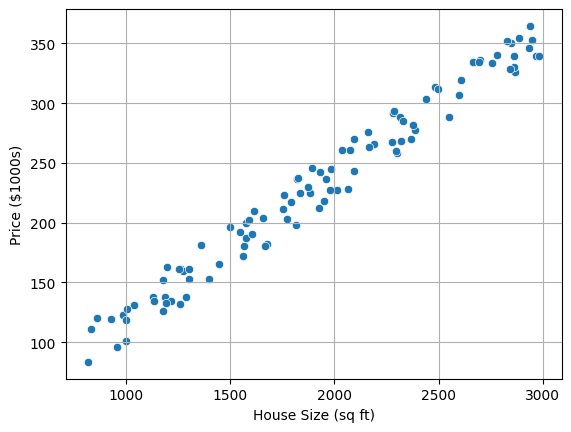

In [7]:
sns.scatterplot(x=data['House Size (sq ft)'],y=data['Price ($1000s)'])
plt.grid()

**Data Visualization**

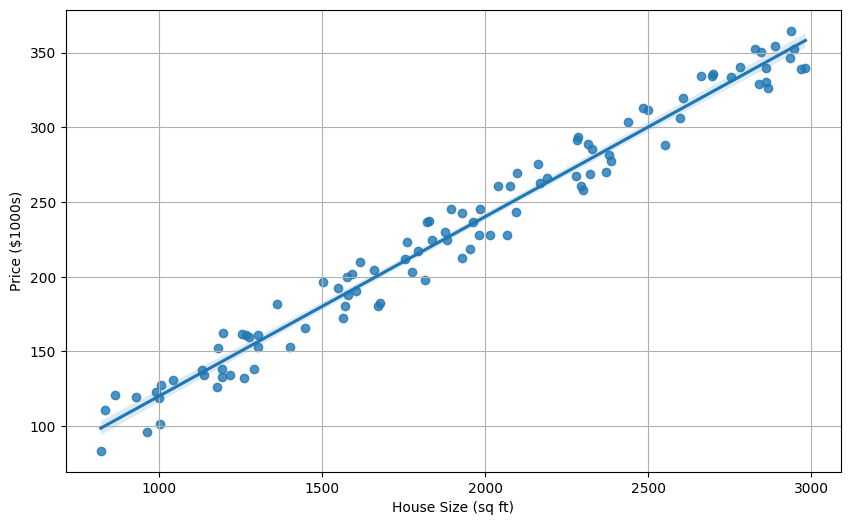

In [8]:
plt.figure(figsize=(10,6))
sns.regplot(x='House Size (sq ft)',y='Price ($1000s)',data=data)
plt.grid()

**Stright line show linear Regression**

In [9]:
X = np.array(data['House Size (sq ft)']).reshape(-1,1)  
y = data['Price ($1000s)']                            

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2) 


In [10]:
X_train.shape

(80, 1)

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression() # Default, fit_intercept=True i.e computes 'b'
# model = LinearRegression(fit_intercept=False)  # Forces 'b' to be 0, No Intercept in case of Mean-Centered Data Only.

model.fit(X_train,y_train)


LinearRegression()

In [12]:
print('Linear Model Coeff(m)', model.coef_) # m/slope
print('Linear Model Coeff(b)', model.intercept_)

Linear Model Coeff(m) [0.12123054]
Linear Model Coeff(b) -2.4887031751588893


In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# Compute errors
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE)  : {mae:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 183.11
Root Mean Squared Error (RMSE): 13.53
Mean Absolute Error (MAE)  : 12.43
R² Score: 0.97


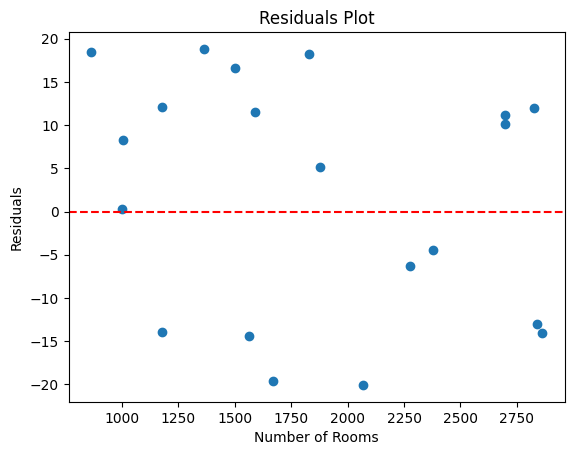

In [15]:
# Calculate residuals (errors)
residuals = y_test - y_pred

plt.scatter(X_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals Plot")
plt.xlabel("Number of Rooms")
plt.ylabel("Residuals")
plt.show()


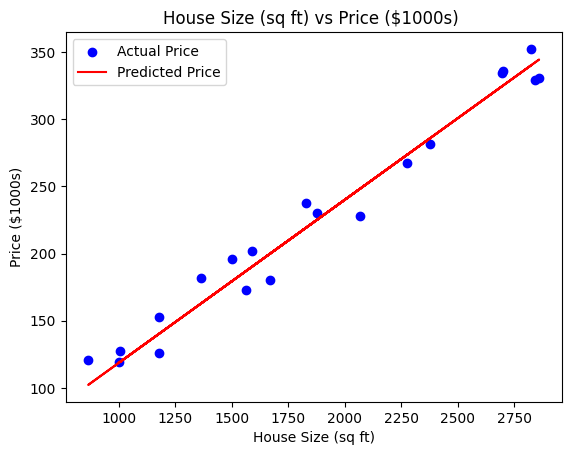

In [16]:
plt.scatter(X_test, y_test, color='blue', label='Actual Price')
plt.plot(X_test, y_pred, color='red', label='Predicted Price')
plt.title("House Size (sq ft) vs Price ($1000s) ")
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price ($1000s)")
plt.legend()
plt.show()


In [17]:
accuracy = model.score(X_test,y_test)
accuracy

0.9700022000093966

now we have **97.52%** accuracy

In [18]:
House = np.array([40])
House = House.reshape(-1,1)

Price = model.predict(House)
print('Price Predictions =', Price)

Price Predictions = [2.36051853]
